In [2]:
# SPLIT TRAIN/TEST SETS

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/preprocessed_texts.csv")

y = df["label"]
X_stopwords = df["text_stopwords"]

X_train, X_test,y_train, y_test =train_test_split(X_stopwords,y,test_size=0.2,random_state=42,stratify=y)

print("train size:",len(X_train), "test size:",len(X_test))
print(y_train.value_counts(normalize= True))

train size: 3876 test size: 970
label
neutral     0.594169
positive    0.281218
negative    0.124613
Name: proportion, dtype: float64


In [3]:
# REUSABLE EVALUATION FUNCTION (defined early so every later cell can call it)

from pathlib import Path
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../results/task3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def evaluate(y_true, y_pred, title=""):
    print(title)
    print(classification_report(y_true, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(title)
    # save a PNG named after the title (spaces/punct -> underscores)
    fname = "".join(c if c.isalnum() else "_" for c in title).strip("_") or "confusion_matrix"
    plt.savefig(OUTPUT_DIR / f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [4]:
# VECTORIZING ( with bag of wordss)

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)


# SPARSITY of the Matrix

print("matrix shape:", X_train_bow.shape)
print("total cells:", X_train_bow.shape[0] * X_train_bow.shape[1])
print("non-zero cells:", X_train_bow.nnz)
print("density: %.4f%%" % (100 * X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1])))


matrix shape: (3876, 8733)
total cells: 33849108
non-zero cells: 46313
density: 0.1368%


In [5]:
# NAIVE BAYES model ( bag of words )

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_bow,y_train)       # learns from training. estimate priors
y_pred = model.predict(X_test_bow)   #outputs predicted label for each row

print(y_pred[:20])
print(len(y_pred))

['neutral' 'neutral' 'neutral' 'positive' 'negative' 'neutral' 'neutral'
 'negative' 'negative' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral'
 'positive' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral']
970


Naive Bayes + BoW
              precision    recall  f1-score   support

    negative       0.69      0.53      0.60       121
     neutral       0.77      0.84      0.81       576
    positive       0.60      0.55      0.57       273

    accuracy                           0.72       970
   macro avg       0.69      0.64      0.66       970
weighted avg       0.71      0.72      0.71       970



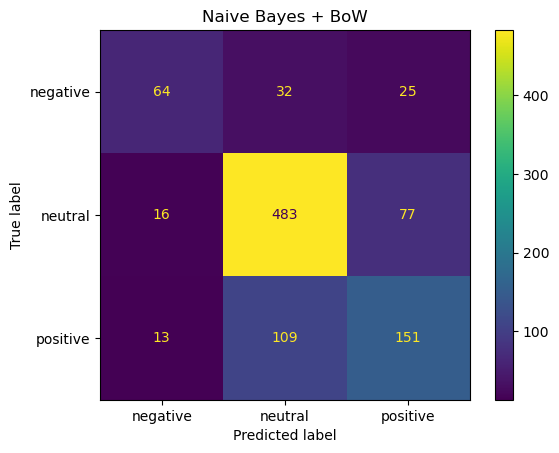

In [6]:
# EVALUATION METRICS (Naive Bayes + BoW)

evaluate(y_test, y_pred, "Naive Bayes + BoW")

In [8]:
# VECTORIZING (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# SPARSITY of the Matrix

print("matrix shape:", X_train_bow.shape)
print("total cells:", X_train_bow.shape[0] * X_train_bow.shape[1])
print("non-zero cells:", X_train_bow.nnz)
print("density: %.4f%%" % (100 * X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1])))


matrix shape: (3876, 8733)
total cells: 33849108
non-zero cells: 46313
density: 0.1368%


Naive Bayes + TF-IDF
              precision    recall  f1-score   support

    negative       0.88      0.06      0.11       121
     neutral       0.69      0.97      0.81       576
    positive       0.61      0.33      0.43       273

    accuracy                           0.68       970
   macro avg       0.73      0.45      0.45       970
weighted avg       0.69      0.68      0.61       970



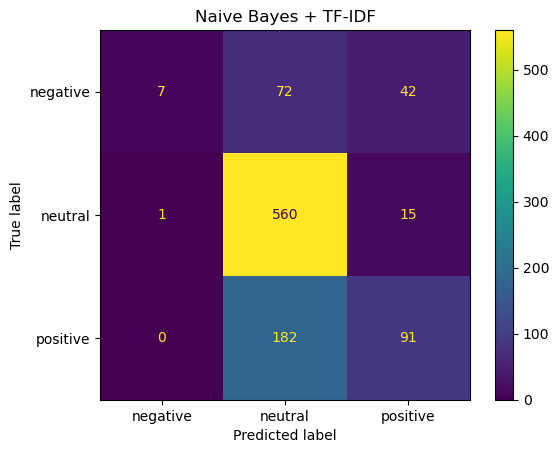

In [9]:
# Naive Bayes  ( TF-IDF )

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

evaluate(y_test, y_pred_tfidf, "Naive Bayes + TF-IDF")


NB + BoW (uniform prior)
              precision    recall  f1-score   support

    negative       0.53      0.63      0.57       121
     neutral       0.79      0.75      0.77       576
    positive       0.56      0.58      0.57       273

    accuracy                           0.68       970
   macro avg       0.63      0.65      0.64       970
weighted avg       0.69      0.68      0.69       970



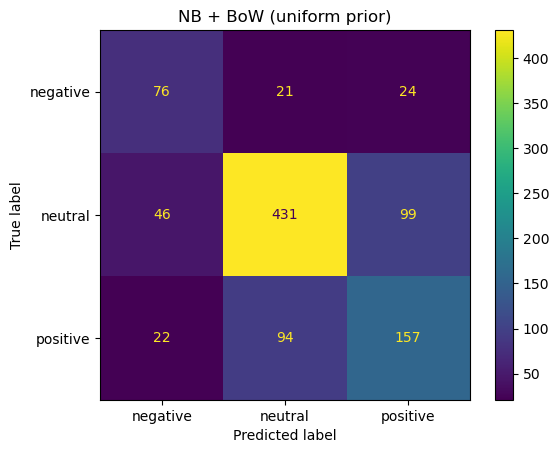

In [11]:
#  Handling class imbalance (uniform prior)

model_fix = MultinomialNB(fit_prior=False)

model_fix.fit(X_train_bow,y_train)
y_pred_fix = model_fix.predict(X_test_bow)
evaluate(y_test, y_pred_fix, "NB + BoW (uniform prior)")

Neural Net + BoW
              precision    recall  f1-score   support

    negative       0.59      0.57      0.58       121
     neutral       0.79      0.81      0.80       576
    positive       0.64      0.62      0.63       273

    accuracy                           0.72       970
   macro avg       0.67      0.67      0.67       970
weighted avg       0.72      0.72      0.72       970



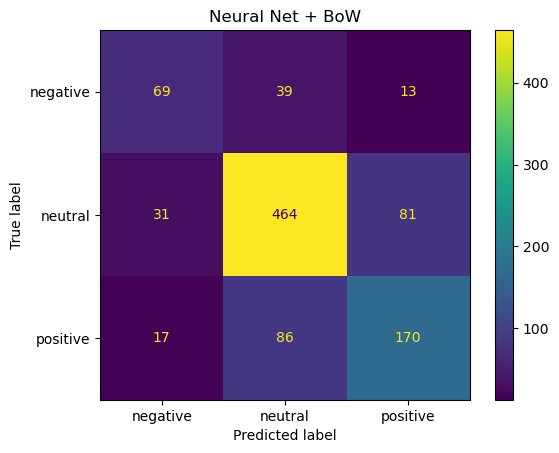

In [12]:
# NEURAL NETWORK (bow)

from sklearn.neural_network import MLPClassifier

model_nn = MLPClassifier(hidden_layer_sizes = (100,), max_iter = 200,
						 random_state = 42)
model_nn.fit(X_train_bow,y_train)
y_pred_nn = model_nn.predict(X_test_bow)
evaluate(y_test, y_pred_nn, "Neural Net + BoW")


In [13]:
# ERROR ANALYSIS

import pandas as pd

results = pd.DataFrame({
    "text": X_test.values,
    "true": y_test.values,
    "pred": y_pred_nn
})

errors = results[results["true"] != results["pred"]]
print("number of errors:", len(errors))

pos_as_neutral = errors[(errors["true"]=="positive") & (errors["pred"]=="neutral")]
pos_as_neutral.head(15)



number of errors: 267


,text,true,pred
6,subscriptions increase cargotec s share capita...,positive,neutral
15,nordea moving new headquarters signifies begin...,positive,neutral
40,staff recruited japan complement network close...,positive,neutral
41,combining deep domain expertise application se...,positive,neutral
44,company featured ethibel pioneer investment re...,positive,neutral
45,paper maker stora enso oyj said friday acquitt...,positive,neutral
49,newly created position established strengthen ...,positive,neutral
67,according schmardin nordea likely try win cust...,positive,neutral
105,asia pacific region visa wave available malays...,positive,neutral
107,cl51 designed measure cloud base height vertic...,positive,neutral


Neural Net + TF-IDF
              precision    recall  f1-score   support

    negative       0.59      0.54      0.56       121
     neutral       0.77      0.80      0.78       576
    positive       0.61      0.60      0.60       273

    accuracy                           0.71       970
   macro avg       0.66      0.64      0.65       970
weighted avg       0.70      0.71      0.71       970



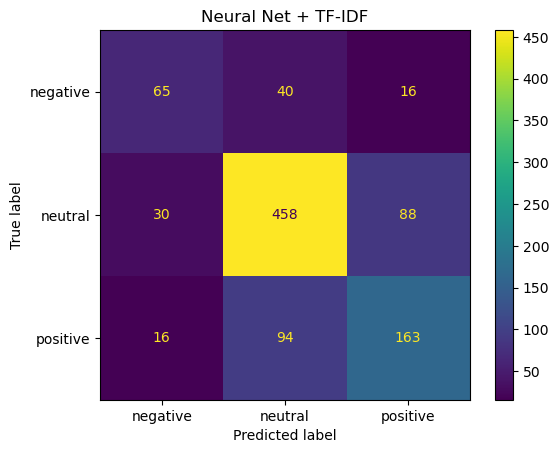

In [15]:
# NEURAL NETWORK (TF-IDF)
model_nn_tfidf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
model_nn_tfidf.fit(X_train_tfidf, y_train)
y_pred_nn_tfidf = model_nn_tfidf.predict(X_test_tfidf)
evaluate(y_test, y_pred_nn_tfidf, "Neural Net + TF-IDF")


In [ ]:
# BINARY setting (removing the neutral)

df_bin = df[df["label"] != "neutral"]

X_bin = df_bin["text_stopwords"]
y_bin = df_bin["label"]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

print("binary dataset size:", len(df_bin))
print(y_train_bin.value_counts(normalize=True))


binary dataset size: 1967
label
positive    0.692943
negative    0.307057
Name: proportion, dtype: float64


NB + BoW (binary)
              precision    recall  f1-score   support

    negative       0.76      0.70      0.73       121
    positive       0.87      0.90      0.89       273

    accuracy                           0.84       394
   macro avg       0.82      0.80      0.81       394
weighted avg       0.84      0.84      0.84       394



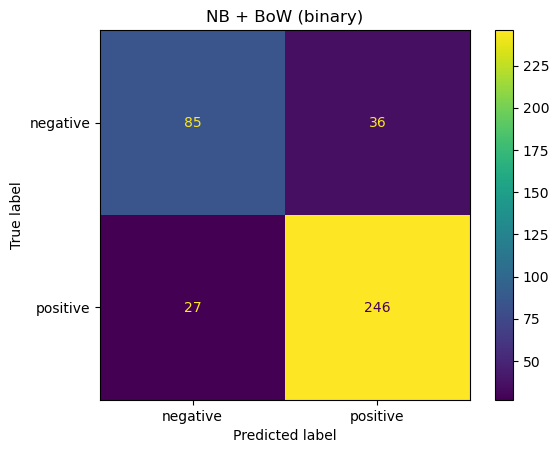

NN + BoW (binary)
              precision    recall  f1-score   support

    negative       0.78      0.74      0.76       121
    positive       0.89      0.91      0.90       273

    accuracy                           0.86       394
   macro avg       0.84      0.83      0.83       394
weighted avg       0.86      0.86      0.86       394



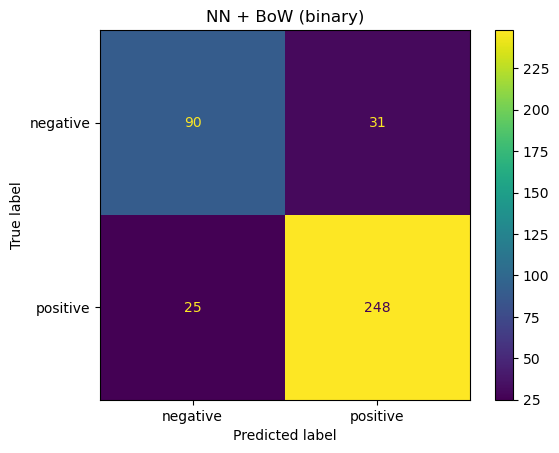

In [19]:
# vectorizing ( bag of words)
vectorizer_bin = CountVectorizer()
X_train_bin_bow = vectorizer_bin.fit_transform(X_train_bin)
X_test_bin_bow = vectorizer_bin.transform(X_test_bin)

# training NB
model_bin_nb = MultinomialNB()
model_bin_nb.fit(X_train_bin_bow, y_train_bin)
y_pred_bin_nb = model_bin_nb.predict(X_test_bin_bow)

# training NN
model_bin_nn = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
model_bin_nn.fit(X_train_bin_bow, y_train_bin)
y_pred_bin_nn = model_bin_nn.predict(X_test_bin_bow)

# evaluating both
evaluate(y_test_bin, y_pred_bin_nb, "NB + BoW (binary)")
evaluate(y_test_bin, y_pred_bin_nn, "NN + BoW (binary)")